In [1]:
!pwd

/mnt/c/Users/vvasileiou/Desktop/lncAPNet/Pilot_1_CLL/notebooks/Post-hoc_Analysis


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [3]:
# Load TSV file
rumma_gene = pd.read_csv("../../results/Rumma/Rumma_Gene.tsv", sep="\t")
rumma_geo = pd.read_csv("../../results/Rumma/Rumma_Geo.tsv", sep="\t")

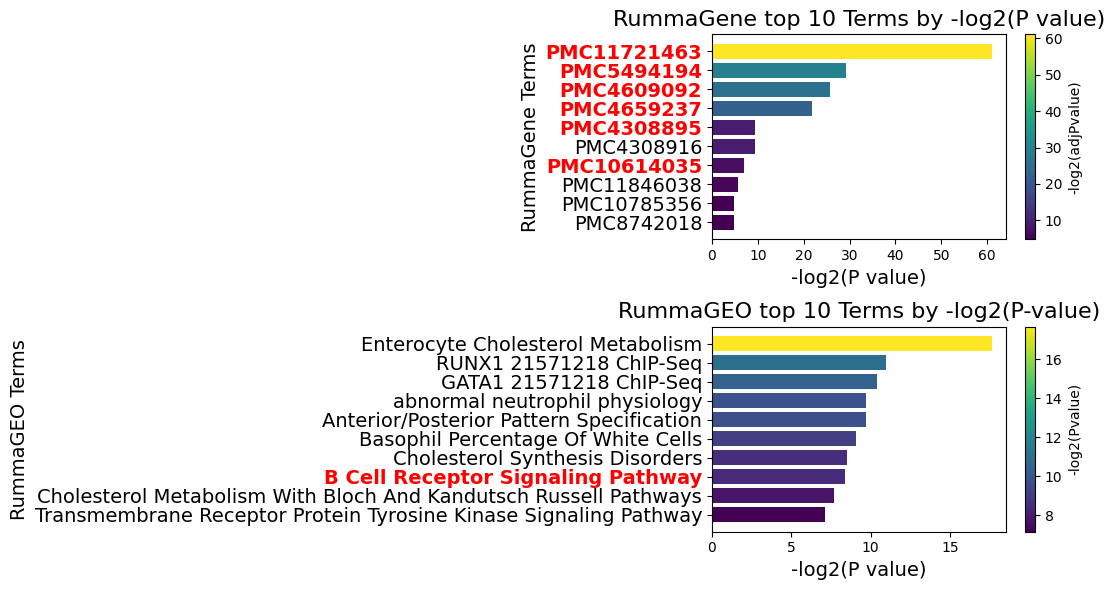

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

# --- Prepare the first dataset: rumma_gene ---
rumma_gene["-log2(adjPvalue)"] = -np.log2(rumma_gene["adjPvalue"])

# Replace long column names with shorter versions
long_name = "Top500_increased_var_genes-Column_ICGC_Top_500_genes_with_increased_variability_in_U-CLL_in_the_ICGC_dataset_total_number_of_genes_analyzed_20_474"
short_name = "Increased_variability_in_U-CLL_in_the_ICGC_dataset"
rumma_gene["column"] = rumma_gene["column"].replace(long_name, short_name)

# --- Remove duplicates by pmcid (keep the lowest adjPvalue per pmcid) ---
rumma_gene = rumma_gene.sort_values("adjPvalue", ascending=True).drop_duplicates("pmcid")

# --- Take top 10 by significance ---
df_top5 = rumma_gene.sort_values("-log2(adjPvalue)", ascending=False).head(10)
df_top5 = df_top5.sort_values("-log2(adjPvalue)", ascending=True)

norm1 = mcolors.Normalize(vmin=df_top5["-log2(adjPvalue)"].min(),
                          vmax=df_top5["-log2(adjPvalue)"].max())
cmap1 = cm.viridis

# Highlight specific pmcids if needed
highlight_pmcs = [
    "PMC11721463",
    "PMC10614035",
    "PMC4308895",
    "PMC4659237",
    "PMC4609092",
    "PMC5494194"
]

# --- Prepare the second dataset: rumma_geo ---
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])

df_top10 = rumma_geo.sort_values("-log2(Pvalue)", ascending=False).head(10)
df_top10 = df_top10.sort_values("-log2(Pvalue)", ascending=True)

# --- Clean up term names ---
def clean_term(term):
    term = re.sub(r"\s+WP\d+$", "", term)
    term = re.sub(r"\s+MP:?\d+$", "", term)
    term = re.sub(r"\s+\(GO:[^)]+\)$", "", term)
    term = re.sub(r"\s+MEGAKARYOCYTES.*$", "", term, flags=re.IGNORECASE)
    term = re.sub(r"\s+MEGAKA\w*$", "", term, flags=re.IGNORECASE)
    return term.strip()

df_top10["term_clean"] = df_top10["term"].apply(clean_term)

norm2 = mcolors.Normalize(vmin=df_top10["-log2(Pvalue)"].min(),
                          vmax=df_top10["-log2(Pvalue)"].max())
cmap2 = cm.viridis

highlight_term = "B Cell Receptor Signaling Pathway"  # cleaned version

# --- Create 2x1 figure ---
fig, axes = plt.subplots(2, 1, figsize=(11, 6))  # 2 rows, 1 column

# --- Font sizes ---
y_label_fontsize = 14
x_label_fontsize = 14
title_fontsize = 16

# --- Top panel: rumma_gene ---
ax = axes[0]
bars1 = ax.barh(
    df_top5["pmcid"],
    df_top5["-log2(adjPvalue)"],
    color=cmap1(norm1(df_top5["-log2(adjPvalue)"]))
)

for label in ax.get_yticklabels():
    label.set_fontsize(y_label_fontsize)
    if label.get_text() in highlight_pmcs:
        label.set_color("red")
        label.set_fontweight("bold")

ax.set_xlabel("-log2(P value)", fontsize=x_label_fontsize)
ax.set_ylabel("RummaGene Terms", fontsize=x_label_fontsize)
ax.set_title("RummaGene top 10 Terms by -log2(P value)", fontsize=title_fontsize)

sm1 = cm.ScalarMappable(cmap=cmap1, norm=norm1)
sm1.set_array([])
fig.colorbar(sm1, ax=ax, label="-log2(adjPvalue)")

# --- Bottom panel: rumma_geo ---
ax = axes[1]
bars2 = ax.barh(
    df_top10["term_clean"],
    df_top10["-log2(Pvalue)"],
    color=cmap2(norm2(df_top10["-log2(Pvalue)"]))
)

for label in ax.get_yticklabels():
    label.set_fontsize(y_label_fontsize)
    if label.get_text() == highlight_term:
        label.set_color("red")
        label.set_fontweight("bold")

ax.set_xlabel("-log2(P value)", fontsize=x_label_fontsize)
ax.set_ylabel("RummaGEO Terms", fontsize=x_label_fontsize)
ax.set_title("RummaGEO top 10 Terms by -log2(P-value)", fontsize=title_fontsize)

sm2 = cm.ScalarMappable(cmap=cmap2, norm=norm2)
sm2.set_array([])
fig.colorbar(sm2, ax=ax, label="-log2(Pvalue)")

# --- Save and show ---
plt.tight_layout()
fig.savefig("../../figures/Rumma_top_panels_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
###### old

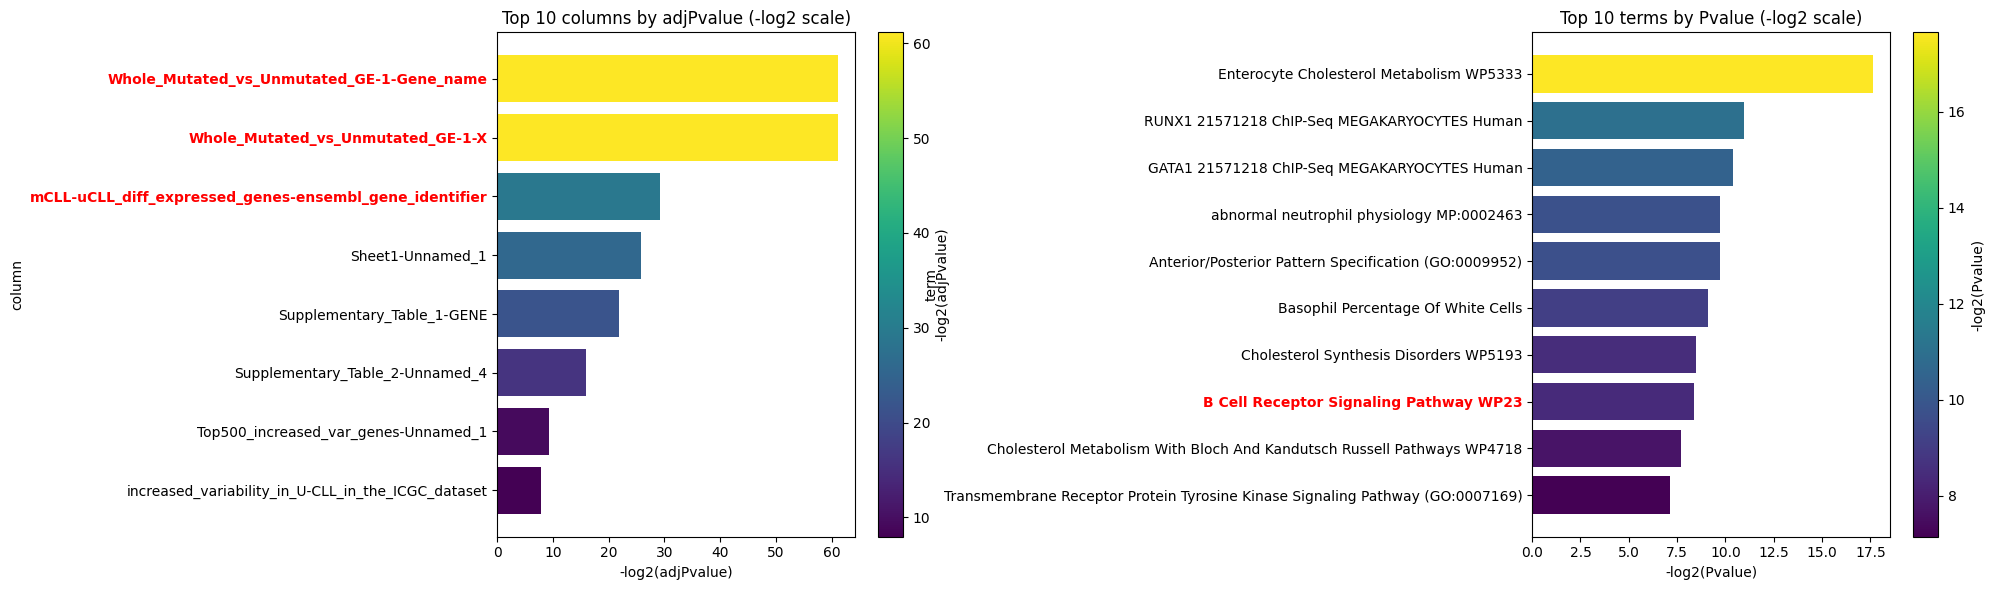

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# --- Prepare the first dataset: rumma_gene ---
rumma_gene["-log2(adjPvalue)"] = -np.log2(rumma_gene["adjPvalue"])

# Replace long column names with shorter versions
long_name = "Top500_increased_var_genes-Column_ICGC_Top_500_genes_with_increased_variability_in_U-CLL_in_the_ICGC_dataset_total_number_of_genes_analyzed_20_474"
short_name = "Increased_variability_in_U-CLL_in_the_ICGC_dataset"
rumma_gene["column"] = rumma_gene["column"].replace(long_name, short_name)

df_top5 = rumma_gene.sort_values("-log2(adjPvalue)", ascending=False).head(10)
df_top5 = df_top5.sort_values("-log2(adjPvalue)", ascending=True)
norm1 = mcolors.Normalize(vmin=df_top5["-log2(adjPvalue)"].min(),
                          vmax=df_top5["-log2(adjPvalue)"].max())
cmap1 = cm.viridis
highlight_cols = [
    "Whole_Mutated_vs_Unmutated_GE-1-Gene_name",
    "Whole_Mutated_vs_Unmutated_GE-1-X",
    "mCLL-uCLL_diff_expressed_genes-ensembl_gene_identifier",
    short_name  # highlight the renamed column too
]

# --- Prepare the second dataset: rumma_geo ---
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])
df_top10 = rumma_geo.sort_values("-log2(Pvalue)", ascending=False).head(10)
df_top10 = df_top10.sort_values("-log2(Pvalue)", ascending=True)
norm2 = mcolors.Normalize(vmin=df_top10["-log2(Pvalue)"].min(),
                          vmax=df_top10["-log2(Pvalue)"].max())
cmap2 = cm.viridis
highlight_term = "B Cell Receptor Signaling Pathway WP23"

# --- Create 1x2 figure ---
fig, axes = plt.subplots(1, 2, figsize=(20, 6))  # 1 row, 2 columns

# --- Left panel: rumma_gene ---
ax = axes[0]
bars1 = ax.barh(
    df_top5["column"],
    df_top5["-log2(adjPvalue)"],
    color=cmap1(norm1(df_top5["-log2(adjPvalue)"]))
)
# Highlight y-axis labels
for label in ax.get_yticklabels():
    if label.get_text() in highlight_cols:
        label.set_color("red")
        label.set_fontweight("bold")
sm1 = cm.ScalarMappable(cmap=cmap1, norm=norm1)
sm1.set_array([])
fig.colorbar(sm1, ax=ax, label="-log2(adjPvalue)")
ax.set_xlabel("-log2(adjPvalue)")
ax.set_ylabel("column")
ax.set_title("Top 10 columns by adjPvalue (-log2 scale)")

# --- Right panel: rumma_geo ---
ax = axes[1]
bars2 = ax.barh(
    df_top10["term"],
    df_top10["-log2(Pvalue)"],
    color=cmap2(norm2(df_top10["-log2(Pvalue)"]))
)
# Highlight y-axis label
for label in ax.get_yticklabels():
    if label.get_text() == highlight_term:
        label.set_color("red")
        label.set_fontweight("bold")
sm2 = cm.ScalarMappable(cmap=cmap2, norm=norm2)
sm2.set_array([])
fig.colorbar(sm2, ax=ax, label="-log2(Pvalue)")
ax.set_xlabel("-log2(Pvalue)")
ax.set_ylabel("term")
ax.set_title("Top 10 terms by Pvalue (-log2 scale)")

plt.tight_layout()
fig.savefig("../../figures/Rumma_top_panels_plot.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
df_top10

,term,CountInEnrichedGSEs,Pvalue,AdjPvalue,-log2(Pvalue),term_clean
19,MTF2 20144788 ChIP-Seq MESCs Mouse,98,0.018344,0.324320,5.768572,MTF2 20144788 ChIP-Seq MESCs Mouse
18,Monocyte Percentage Of White Cells,13,0.018275,0.324320,5.774014,Monocyte Percentage Of White Cells
17,Oxidative phosphorylation,5,0.017820,0.324320,5.810383,Oxidative phosphorylation
16,Parkinson disease,16,0.016427,0.324320,5.927757,Parkinson disease
15,Extracellular Matrix Organization (GO:0030198),52,0.014854,0.324320,6.072972,Extracellular Matrix Organization
14,Phagosome,27,0.014189,0.324320,6.139095,Phagosome
13,Electron Transport Chain OXPHOS System In Mito...,9,0.011851,0.311508,6.398868,Electron Transport Chain OXPHOS System In Mito...
12,B Cell Receptor Signaling Pathway (GO:0050853),13,0.010307,0.291771,6.600214,B Cell Receptor Signaling Pathway
11,Dilatation of the ascending aorta (HP:0005111),6,0.010012,0.291771,6.642060,Dilatation of the ascending aorta (HP:0005111)
10,Adolescent Idiopathic Scoliosis,5,0.007625,0.255094,7.035029,Adolescent Idiopathic Scoliosis


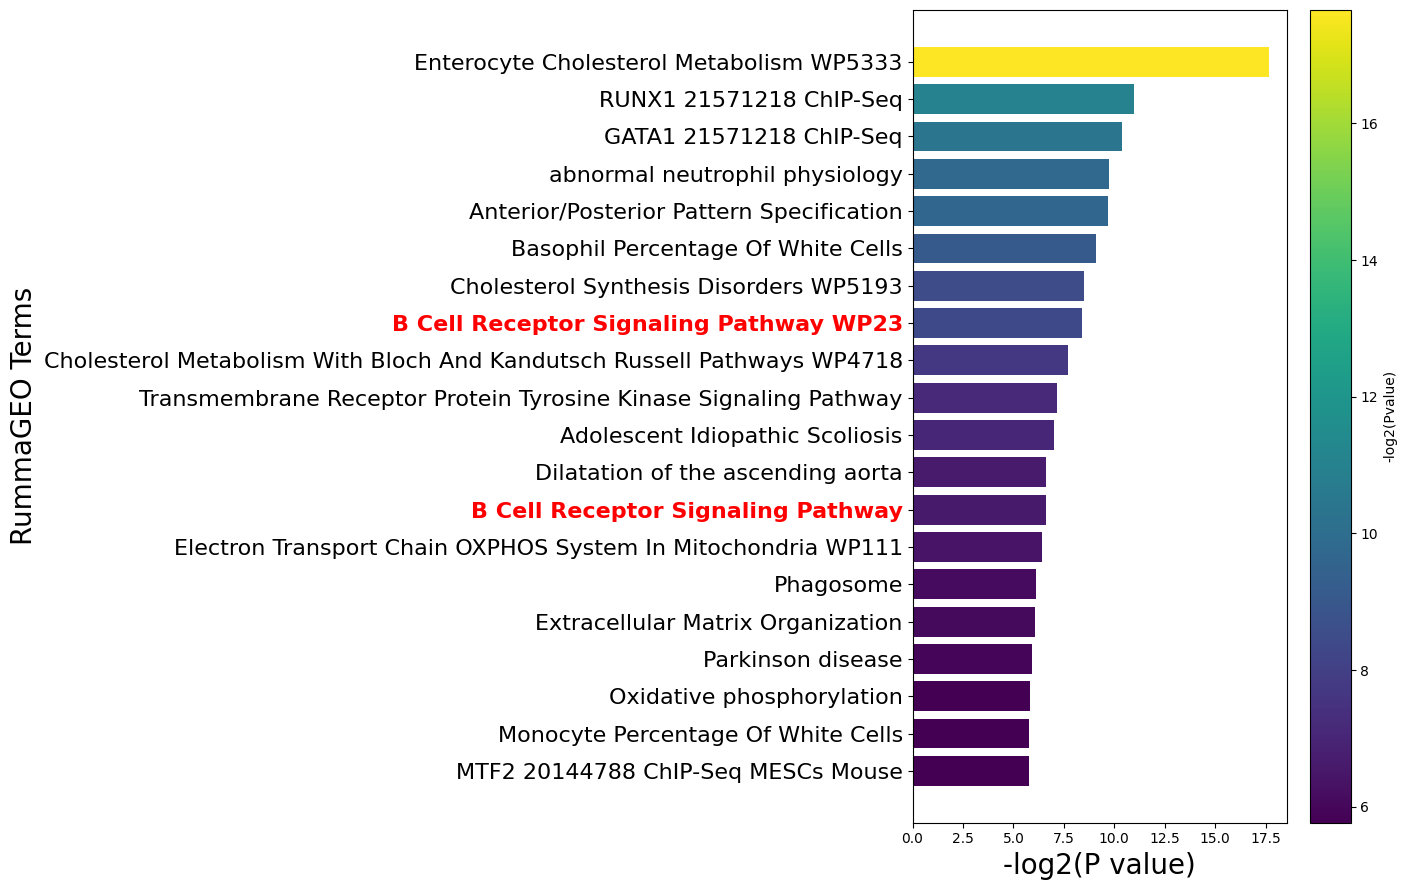

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import re

# -------------------------------------------------------------------
# Prepare dataset
# -------------------------------------------------------------------
rumma_geo["-log2(Pvalue)"] = -np.log2(rumma_geo["Pvalue"])

df_top10 = (
    rumma_geo
    .sort_values("-log2(Pvalue)", ascending=False)
    .head(20)
    .sort_values("-log2(Pvalue)", ascending=True)
)

# -------------------------------------------------------------------
# Clean up term names
# -------------------------------------------------------------------
def clean_term(term):
    term = re.sub(r"\s+MP:?\d+$", "", term)
    term = re.sub(r"\s+\(GO:[^)]+\)$", "", term)
    term = re.sub(r"\s+\(HP:[^)]+\)$", "", term)
    term = re.sub(r"\s+MEGAKARYOCYTES.*$", "", term, flags=re.IGNORECASE)
    term = re.sub(r"\s+MEGKA\w*$", "", term, flags=re.IGNORECASE)
    return term.strip()

df_top10["term_clean"] = df_top10["term"].apply(clean_term)

# -------------------------------------------------------------------
# Coloring
# -------------------------------------------------------------------
norm = mcolors.Normalize(
    vmin=df_top10["-log2(Pvalue)"].min(),
    vmax=df_top10["-log2(Pvalue)"].max()
)
cmap = cm.viridis

# Term(s) to highlight based on substring
highlight_keywords = ["b cell receptor signaling pathway"]

# -------------------------------------------------------------------
# Create figure
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 9))

bars = ax.barh(
    df_top10["term_clean"],
    df_top10["-log2(Pvalue)"],
    color=cmap(norm(df_top10["-log2(Pvalue)"]))
)

# -------------------------------------------------------------------
# Highlight ONLY y-axis labels (not bars)
# -------------------------------------------------------------------
for label in ax.get_yticklabels():
    text = label.get_text().lower()
    label.set_fontsize(16)

    if any(keyword in text for keyword in highlight_keywords):
        label.set_color("red")
        label.set_fontweight("bold")

# -------------------------------------------------------------------
# Labels and aesthetics
# -------------------------------------------------------------------
ax.set_xlabel("-log2(P value)", fontsize=20)
ax.set_ylabel("RummaGEO Terms", fontsize=20)
#ax.set_title("RummaGEO Top 10 Terms by -log2(P-value)", fontsize=20, loc="left")

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label="-log2(Pvalue)")

plt.tight_layout()
fig.savefig("../../figures/RummaGEO_plot.png", dpi=300, bbox_inches="tight")
plt.show()
